# Forward (noising) process

This notebook implements and visualizes the forward diffusion process — the half of DDPM that gradually corrupts a clean image into pure Gaussian noise. The reverse process, which the neural network learns, comes in a later notebook.

## Setup

A diffusion model defines a Markov chain that maps a clean image $x_0$ to pure noise $x_T$ through a sequence of small noising steps. At each step, a small amount of Gaussian noise is added:

$$
q(x_t \mid x_{t-1}) = \mathcal{N}\big(x_t;\, \sqrt{1 - \beta_t}\, x_{t-1},\, \beta_t I\big)
$$

where $\{\beta_t\}_{t=1}^{T}$ is a noise schedule controlling how much noise is added at each step. With small enough $\beta_t$ and large enough $T$, the marginal at $t = T$ approaches an isotropic Gaussian, $q(x_T) \approx \mathcal{N}(0, I)$.

## Closed-form sampling

A useful property of this chain is that we can sample $x_t$ directly from $x_0$ without iterating step by step. Define:

$$
\alpha_t = 1 - \beta_t,\qquad \bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s
$$

Then the marginal at any timestep has a closed form:

$$
q(x_t \mid x_0) = \mathcal{N}\big(x_t;\, \sqrt{\bar{\alpha}_t}\, x_0,\, (1 - \bar{\alpha}_t) I\big)
$$

which gives the reparameterized sample:

$$
x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon,\qquad \epsilon \sim \mathcal{N}(0, I)
$$

This is what makes training tractable: at each training step we pick a random $t$, jump directly to $x_t$, and ask the model to predict the noise $\epsilon$ that was added — no iteration through intermediate timesteps required.

## What this notebook does

1. Defines a linear $\beta$ schedule with $T = 200$.
2. Computes the derived quantities $\alpha_t$ and $\bar{\alpha}_t$.
3. Implements `q_sample(x_0, t)` using the closed-form expression above.
4. Visualizes the noising process on an MNIST digit at increasing timesteps.

---

*Reference: Ho, Jain, Abbeel — Denoising Diffusion Probabilistic Models (2020), [arXiv:2006.11239](https://arxiv.org/abs/2006.11239).*

In [1]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Hyperparameters
T = 200
beta_start = 1e-4
beta_end = 0.02

# Linear beta schedule
betas = torch.linspace(beta_start, beta_end, T)

# Derived quantities
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

print(f"betas[0]            = {betas[0]:.6f}")
print(f"betas[-1]           = {betas[-1]:.6f}")
print(f"alphas_cumprod[0]   = {alphas_cumprod[0]:.6f}")
print(f"alphas_cumprod[-1]  = {alphas_cumprod[-1]:.6f}")

betas[0]            = 0.000100
betas[-1]           = 0.020000
alphas_cumprod[0]   = 0.999900
alphas_cumprod[-1]  = 0.132183


In [2]:
def q_sample(x0, t, noise=None):
    """
    Sample x_t given x_0 in closed form:
        x_t = sqrt(alpha_cumprod_t) * x_0 + sqrt(1 - alpha_cumprod_t) * noise
    
    x0    : tensor of shape (B, C, H, W), values in [-1, 1]
    t     : tensor of shape (B,), int timesteps in [0, T-1]
    noise : optional pre-sampled noise of same shape as x0
    """
    if noise is None:
        noise = torch.randn_like(x0)
    
    sqrt_alpha           = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    
    return sqrt_alpha * x0 + sqrt_one_minus_alpha * noise

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 356kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.48MB/s]


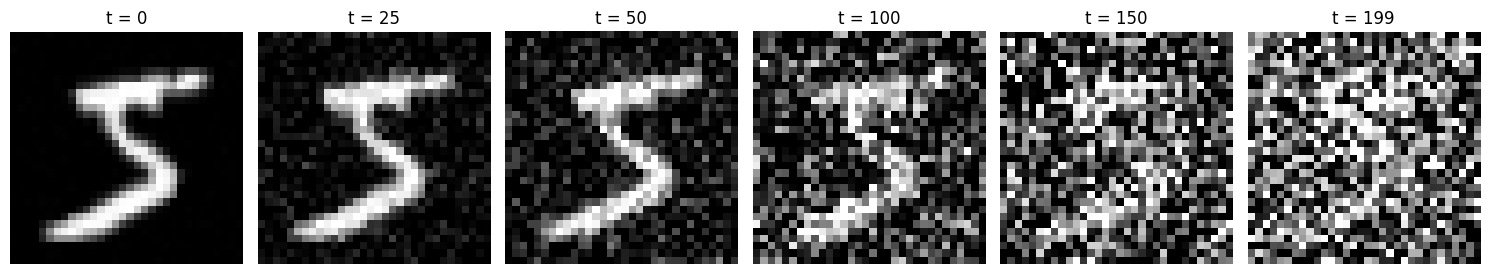

In [3]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
x0, label = dataset[0]
x0 = x0.unsqueeze(0)  # add batch dim -> [1, 1, 32, 32]

timesteps_to_show = [0, 25, 50, 100, 150, 199]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))
for ax, t_val in zip(axes, timesteps_to_show):
    t = torch.tensor([t_val])
    x_t = q_sample(x0, t)
    img = ((x_t.squeeze() + 1) / 2).clamp(0, 1)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"t = {t_val}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("forward_process.png", dpi=100, bbox_inches="tight")
plt.show()